In [1]:
import numpy as np
import random
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
csv_path = "./csvs/detsum_proposal_sample_v0/"

lf_df = pd.read_csv(csv_path + 'lf.csv')
hf_train_df = pd.read_csv(csv_path + 'hf_train.csv')
hf_valid_df = pd.read_csv(csv_path + 'hf_valid.csv')

In [3]:
lf_df

,event_number,etau,alpha,beta,genie_nmult,genie_np,genie_npi0,genie_npic,genie_sum_px,genie_sum_py,genie_sum_pz,genie_sum_ke,genie_sphericity,genie_aplanarity,nnbar_score,pass_cut
0,0,5.0,0.87,0.206,7,0,1,3,0.140443,0.491348,-0.486397,1.388915,0.627121,0.030118,0.955976,True
1,1,5.0,0.87,0.206,23,4,1,1,0.003293,-0.113451,-0.313063,2.057566,0.643195,0.155357,0.929995,False
2,2,5.0,0.87,0.206,15,3,2,3,-0.816539,-0.262643,-0.327602,1.446787,0.617787,0.059570,0.945252,False
3,3,5.0,0.87,0.206,3,0,1,2,-0.184809,-0.006740,0.207769,1.546931,0.015888,0.002276,0.155386,False
4,4,5.0,0.87,0.206,12,3,1,3,-0.284557,-0.667734,-0.806400,1.616599,0.503623,0.160665,0.784397,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85607,85607,30.0,0.99,0.218,31,9,0,1,0.086957,1.294552,-0.042159,2.123196,0.721110,0.269062,0.941342,False
85608,85608,30.0,0.99,0.218,32,5,2,1,0.927798,-0.115501,-2.053812,2.354698,0.854376,0.372602,0.667299,False
85609,85609,30.0,0.99,0.218,6,0,1,4,0.046160,0.475306,0.176922,1.174922,0.480624,0.143860,0.769147,False
85610,85610,30.0,0.99,0.218,22,6,1,0,-1.584892,-2.005521,1.666202,2.810747,0.464286,0.082170,0.224145,False


### 2) plot nnbarscore

In [4]:
def plot_nnbar_points_with_errors(df, column, bins=50, range=(0, 1)):
    """
    Plots nnbar_score distribution as data points with statistical 
    error bars for each parameter group.
    """
    # Load data
    group_cols = ['etau', 'alpha', 'beta']
    groups = df.groupby(group_cols)
    
    plt.figure(figsize=(10, 6))
    
    for name, group in groups:
        label = f"τ_e={name[0]}, α={name[1]}, β'={name[2]}"
        scores = group[column].values
        
        # 1. Calculate the histogram counts and bin edges
        counts, bin_edges = np.histogram(scores, bins=bins, range=range)
        
        # 2. Calculate bin centers and widths
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 3. Calculate Poisson errors (sqrt(N))
        errors = np.sqrt(counts)
        
        # 4. Normalize to Probability Density
        # Density = Count / (Total_Events * Bin_Width)
        total_events = len(scores)
        density = counts / (total_events * bin_width)
        density_errors = errors / (total_events * bin_width)
        
        # 5. Mask zero bins for a cleaner plot (optional)
        mask = counts > 0
        
        # 6. Plot using errorbar
        plt.errorbar(
            bin_centers[mask], 
            density[mask], 
            yerr=density_errors[mask], 
            fmt='o',           # 'o' for circle markers
            markersize=5, 
            capsize=3,         # Horizontal caps on error bars
            label=f"{label} (N={total_events})",
            linestyle='None'   # Do not connect the dots
        )

    plt.title(f'Comparison of {column} Distributions (Statistical Errors)', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(title="Parameter Sets", bbox_to_anchor=(0.15, 1), loc='upper left')
    #plt.legend(title="Parameter Sets", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save or show
    plt.savefig(f'{column}_points_with_errors.png')
    plt.show()

# Execution
# plot_nnbar_points_with_errors(lf_df, 'nnbar_score')

In [9]:
def plot_nnbar_points_with_errors(df, column, bins=50, plot_range=(0, 1)):
    group_cols = ['etau', 'alpha', 'beta']
    groups = df.groupby(group_cols)
    
    plt.figure(figsize=(10, 6))
    
    for name, group in groups:
        # Use LaTeX formatting for the label to look professional
        label = r"$\tau_e$={:.1f}, $\alpha$={:.2f}, $\beta$={:.3f}".format(*name)
        scores = group[column].values
        
        # 1. Calculate the histogram using the specified range
        counts, bin_edges = np.histogram(scores, bins=bins, range=plot_range)
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 2. Poisson Errors
        errors = np.sqrt(counts)
        
        # 3. Density Normalization
        total_events = len(scores)
        if total_events == 0: continue
            
        density = counts / (total_events * bin_width)
        density_errors = errors / (total_events * bin_width)
        
        # 4. Mask zeros so we don't plot points at y=0
        mask = counts > 0
        
        plt.errorbar(
            bin_centers[mask], 
            density[mask], 
            yerr=density_errors[mask], 
            fmt='o', 
            markersize=4, 
            capsize=2,
            label=f"{label} (N={total_events})",
            linestyle='None'
        )

    # CRITICAL: Set the limits explicitly
    plt.xlim(plot_range) 
    
    plt.title(f'Comparison of {column} Distributions', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Adjusted legend to not overlap data
    #plt.legend(title="Parameter Sets", loc='best', fontsize='small', frameon=True)
    #plt.legend(title="Parameter Sets", loc=(1.05, 0), fontsize='small', frameon=True, ncol=2)
    plt.legend(title="Parameters", loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', frameon=True)

    plt.tight_layout()
    plt.savefig(f'{column}_points_with_errors.png', dpi=300)
    plt.show()

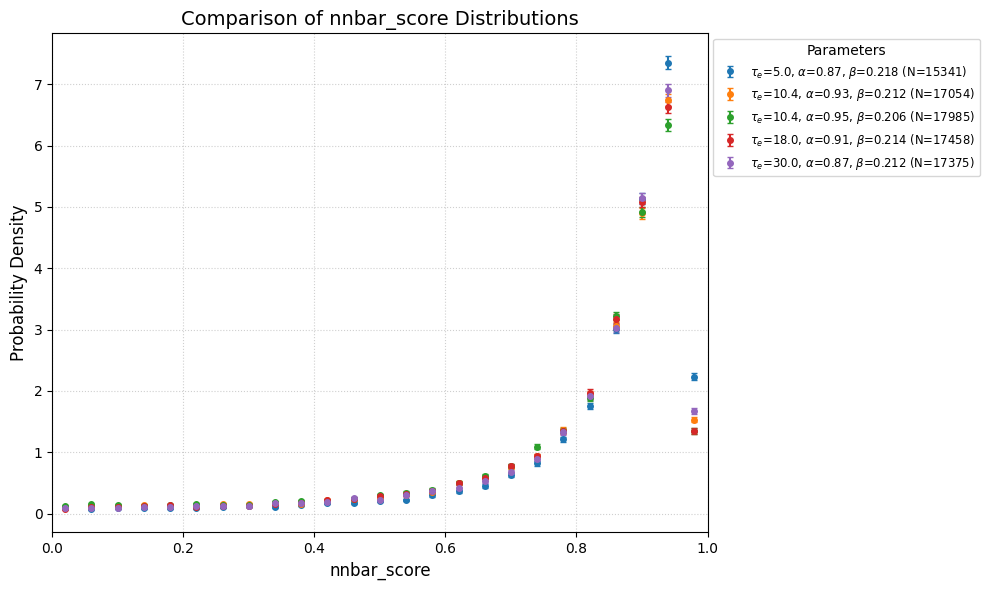

/var/folders/tj/3kjxrxwx2c37zmf4n9j5yh900000gq/T/ipykernel_92297/908693390.py:13: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  counts, bin_edges = np.histogram(scores, bins=bins, range=plot_range)


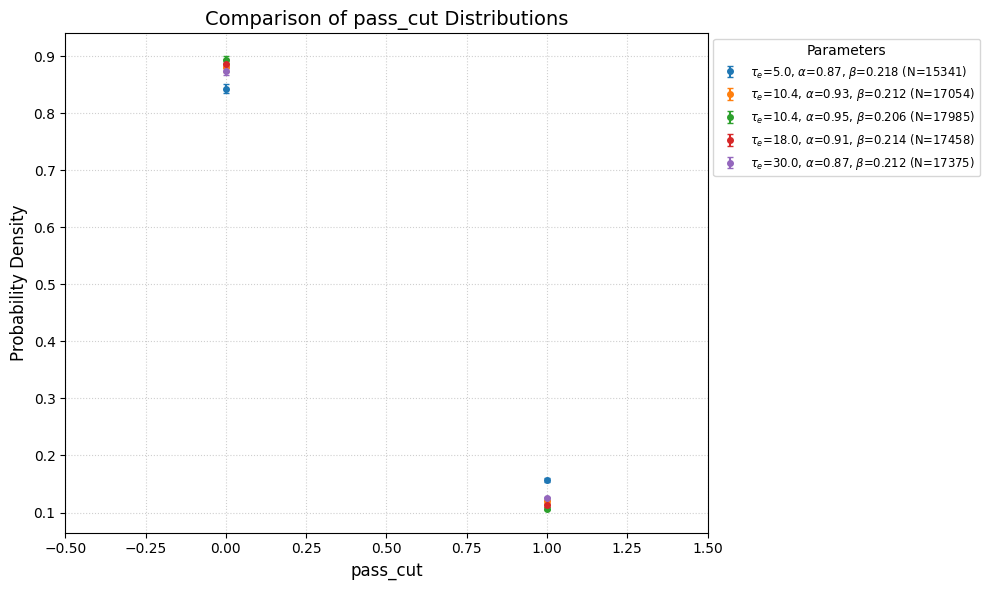

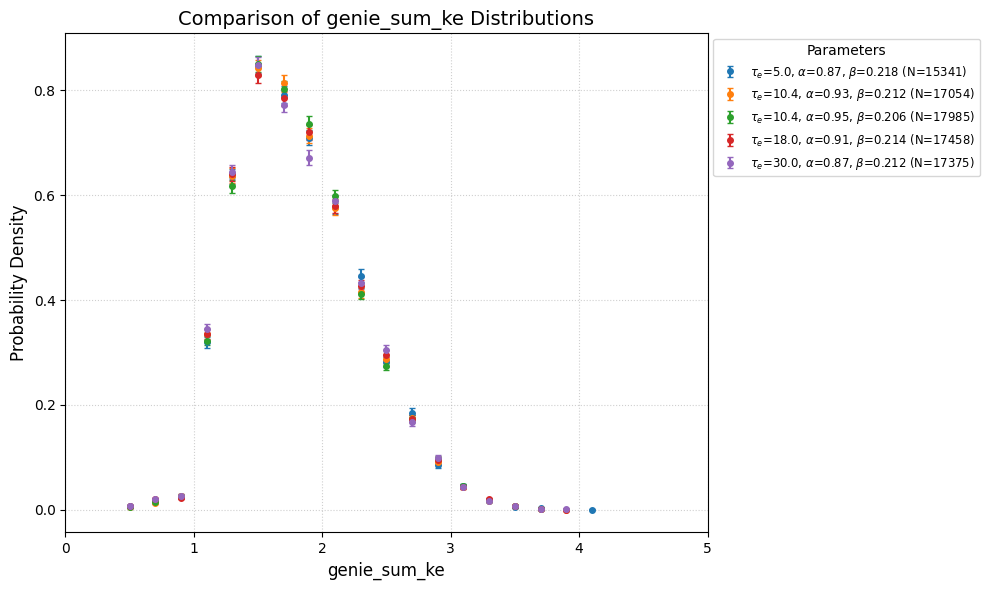

In [10]:
plot_nnbar_points_with_errors(hf_train_df, 'nnbar_score', bins=25, plot_range=(0, 1))
plot_nnbar_points_with_errors(hf_train_df, 'pass_cut', bins=2, plot_range=(-0.5, 1.5))
plot_nnbar_points_with_errors(hf_train_df, 'genie_sum_ke', bins=25, plot_range=(0., 5.))

In [11]:
def plot_nnbar_points_with_errors_each_etau(df, column, bins=50, plot_range=(0, 1)):
    # Group by etau first to create individual plots
    etau_values = df['etau'].unique()
    
    for etau in etau_values:
        # Filter dataframe for the current etau
        etau_df = df[df['etau'] == etau]
        
        # Now group by alpha and beta for the lines in this specific plot
        group_cols = ['alpha', 'beta']
        groups = etau_df.groupby(group_cols)
        
        plt.figure(figsize=(10, 6))
        
        for (alpha, beta), group in groups:
            # Professional LaTeX label
            label = rf"$\alpha$={alpha:.2f}, $\beta$={beta:.3f}"
            scores = group[column].values
            
            # 1. Calculate the histogram
            counts, bin_edges = np.histogram(scores, bins=bins, range=plot_range)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            bin_width = bin_edges[1] - bin_edges[0]
            
            # 2. Poisson Errors
            errors = np.sqrt(counts)
            
            # 3. Density Normalization
            total_events = len(scores)
            if total_events == 0: continue
                
            density = counts / (total_events * bin_width)
            density_errors = errors / (total_events * bin_width)
            
            # 4. Mask zeros
            mask = counts > 0
            
            plt.errorbar(
                bin_centers[mask], 
                density[mask], 
                yerr=density_errors[mask], 
                fmt='o', 
                markersize=4, 
                capsize=2,
                label=f"{label} (N={total_events})",
                linestyle='None'
            )

        plt.xlim(plot_range) 
        plt.title(f'Distribution of {column} for $\\tau_e$ = {etau}', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Probability Density', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        
        # Legend outside the plot
        plt.legend(title="Parameters", loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', frameon=True)
        
        plt.tight_layout()
        # Unique filename per etau
        plt.savefig(f'{column}_etau_{etau}_errors.png', dpi=300, bbox_inches='tight')
        plt.show()

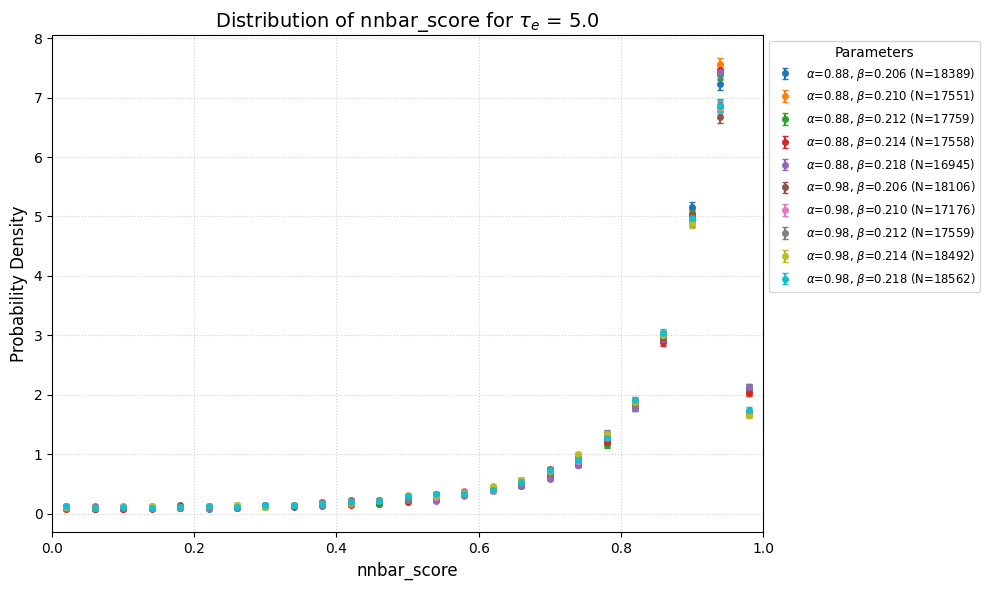

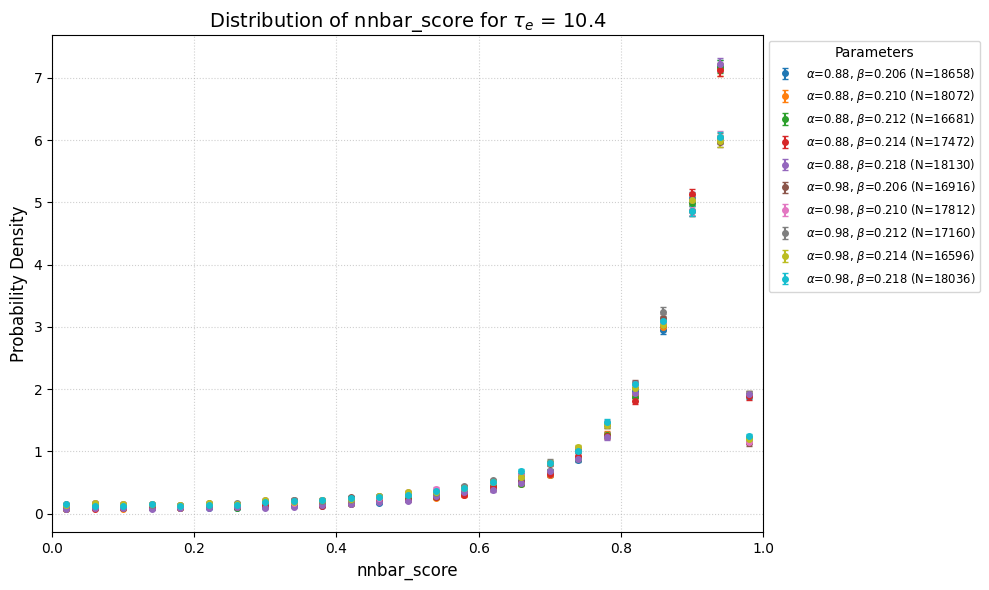

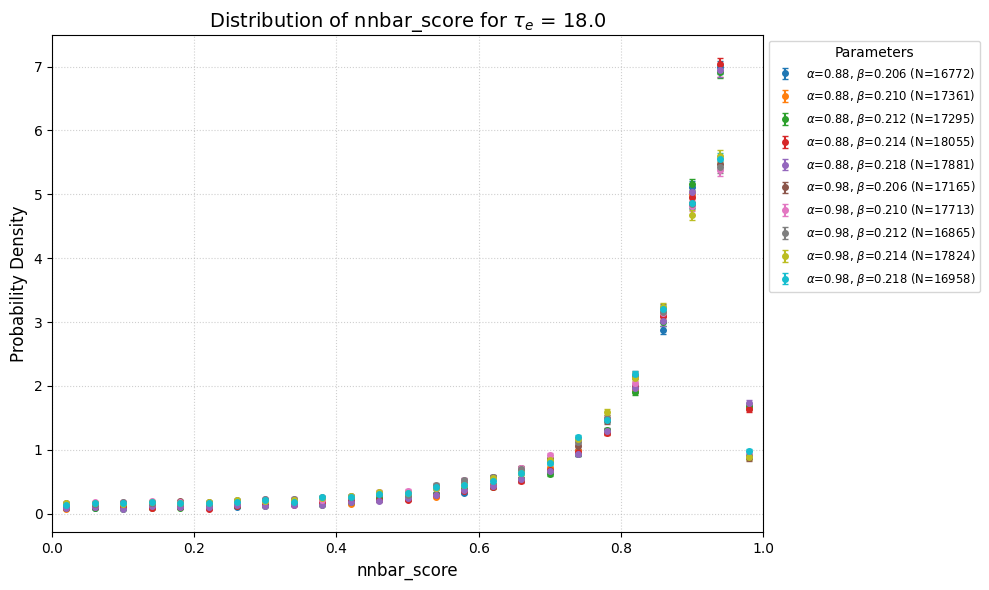

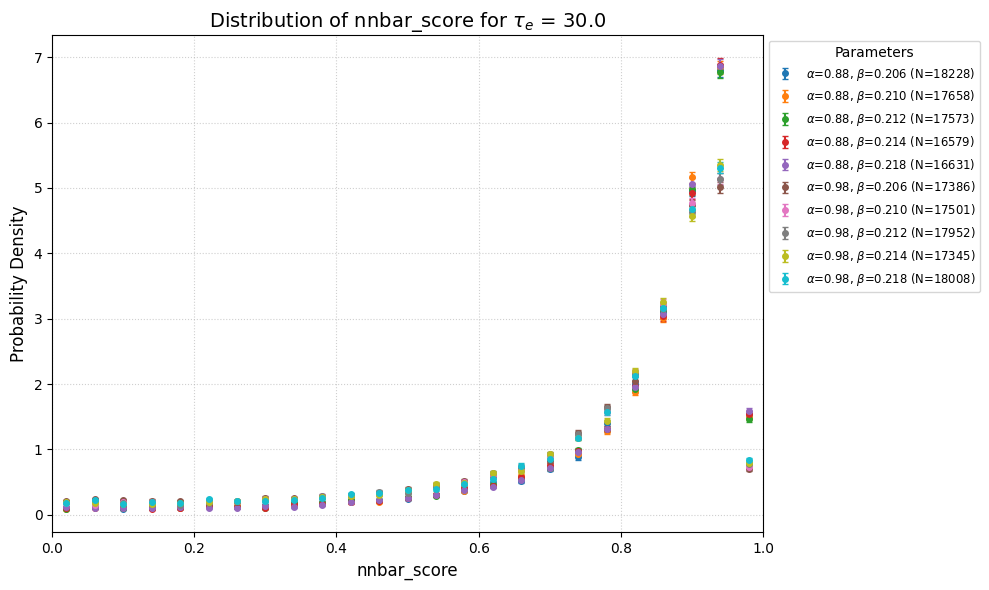

/var/folders/tj/3kjxrxwx2c37zmf4n9j5yh900000gq/T/ipykernel_92297/4266735449.py:21: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  counts, bin_edges = np.histogram(scores, bins=bins, range=plot_range)


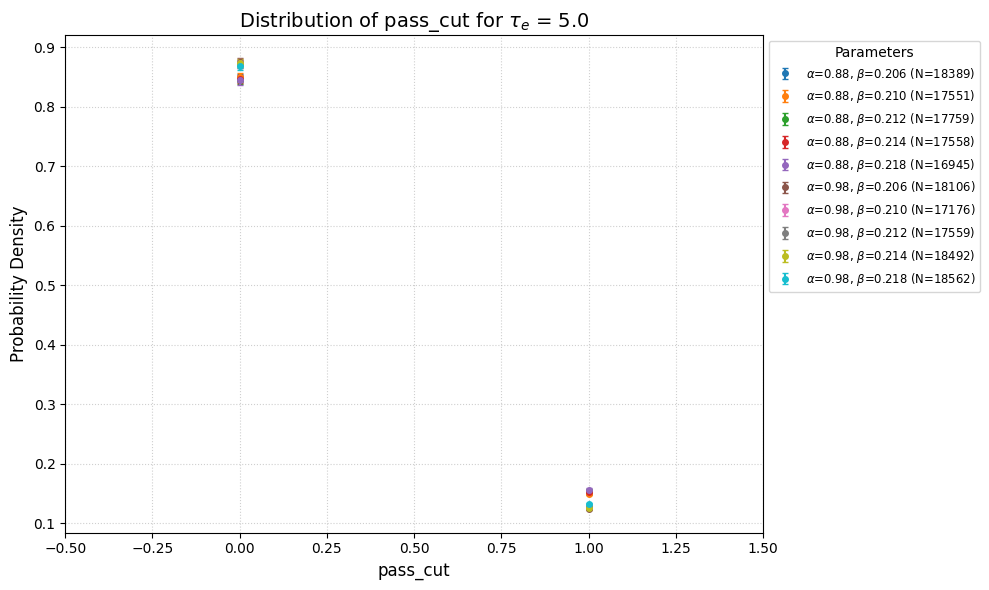

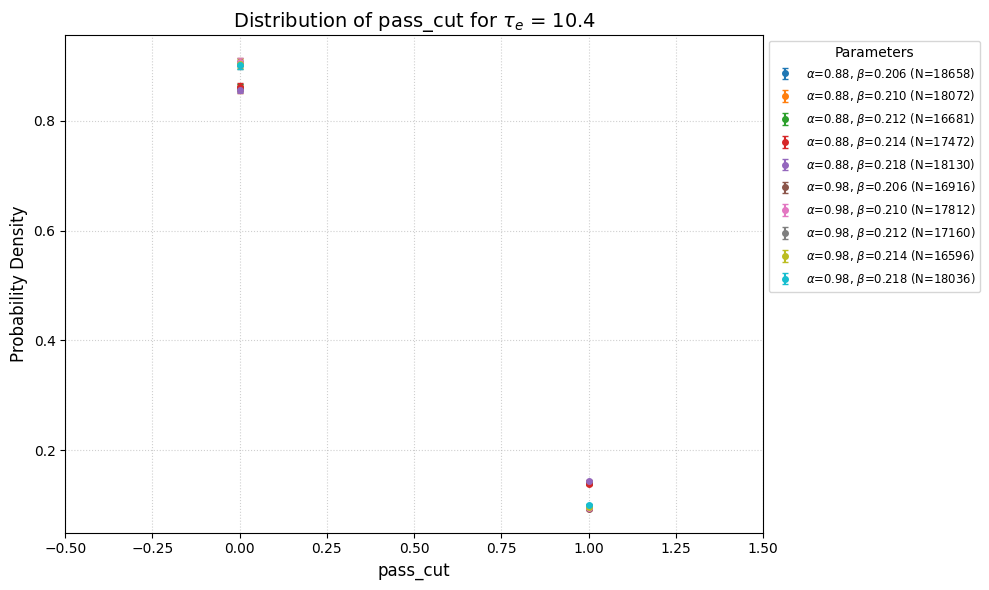

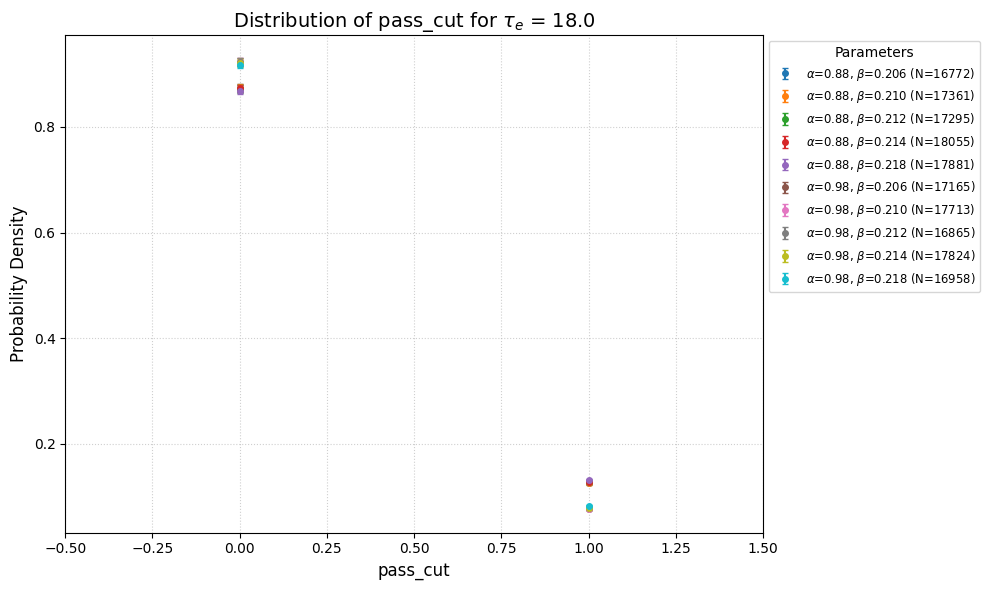

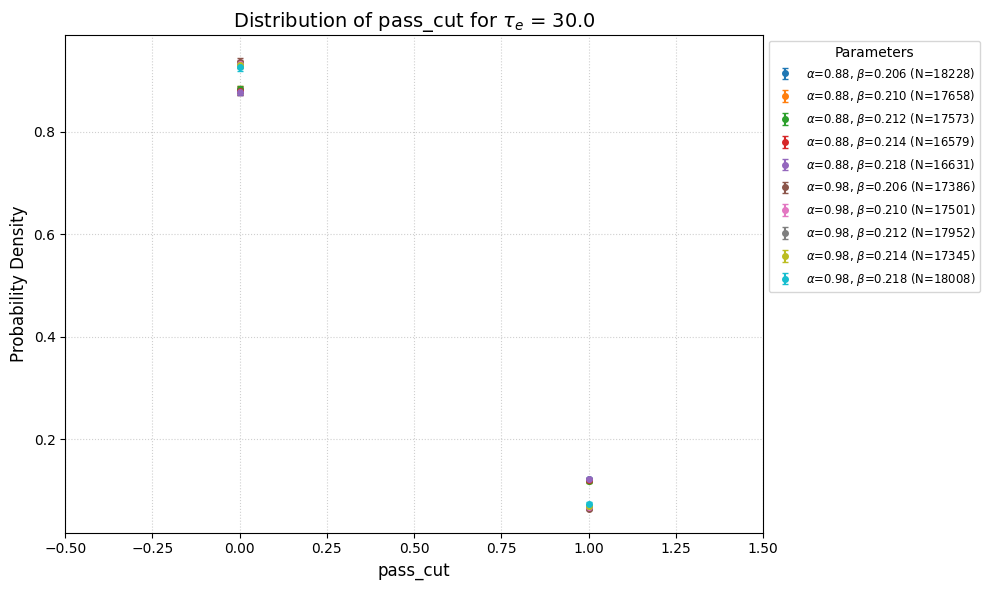

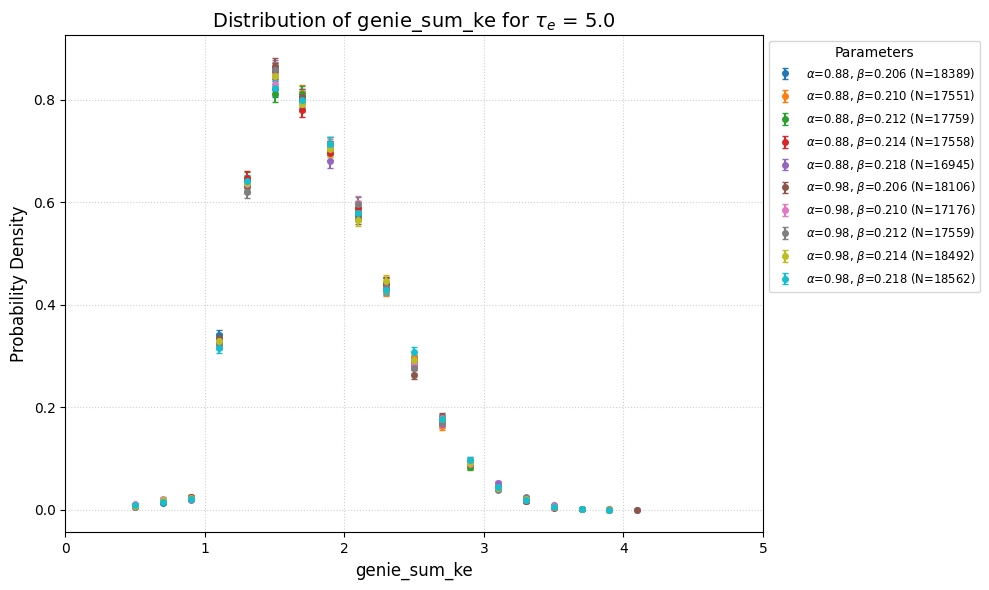

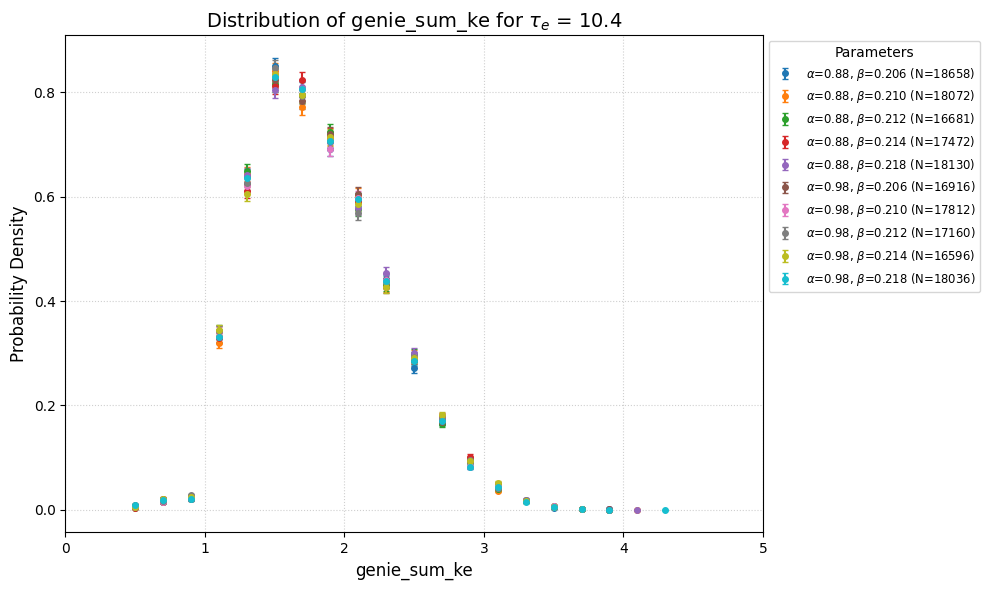

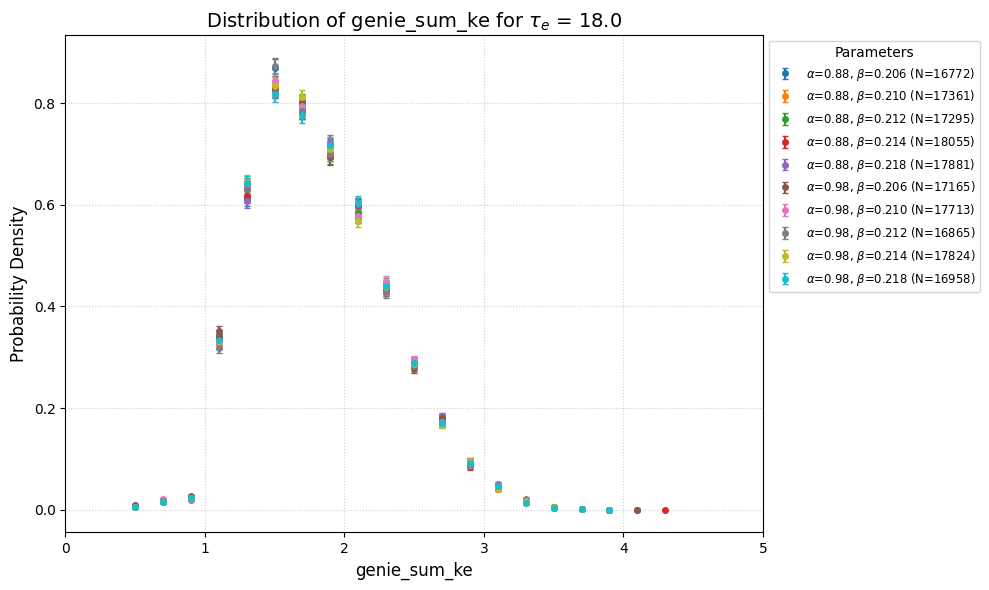

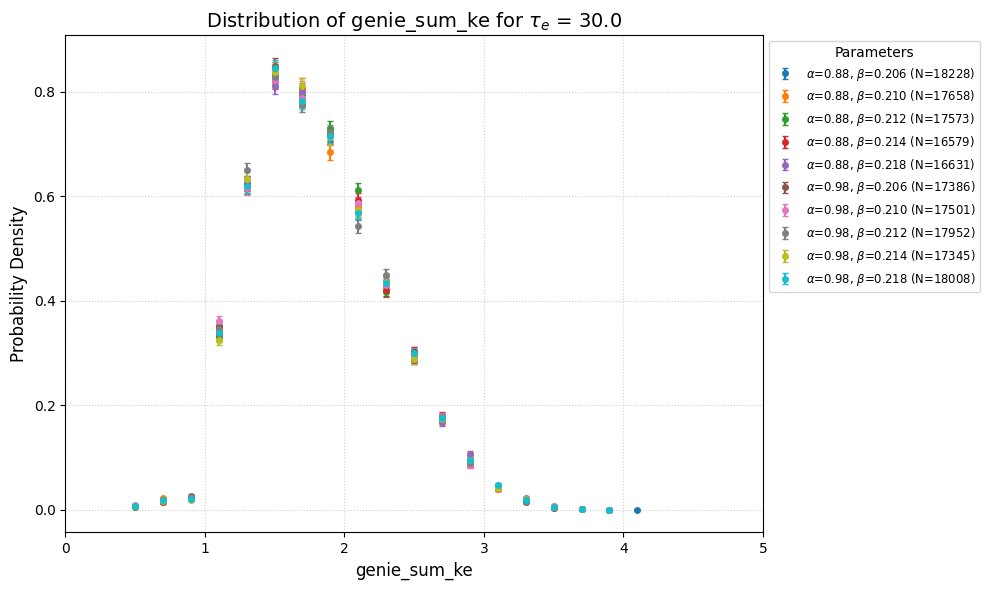

In [12]:
plot_nnbar_points_with_errors_each_etau(hf_valid_df, 'nnbar_score', bins=25, plot_range=(0, 1))
plot_nnbar_points_with_errors_each_etau(hf_valid_df, 'pass_cut', bins=2, plot_range=(-0.5, 1.5))
plot_nnbar_points_with_errors_each_etau(hf_valid_df, 'genie_sum_ke', bins=25, plot_range=(0., 5.))

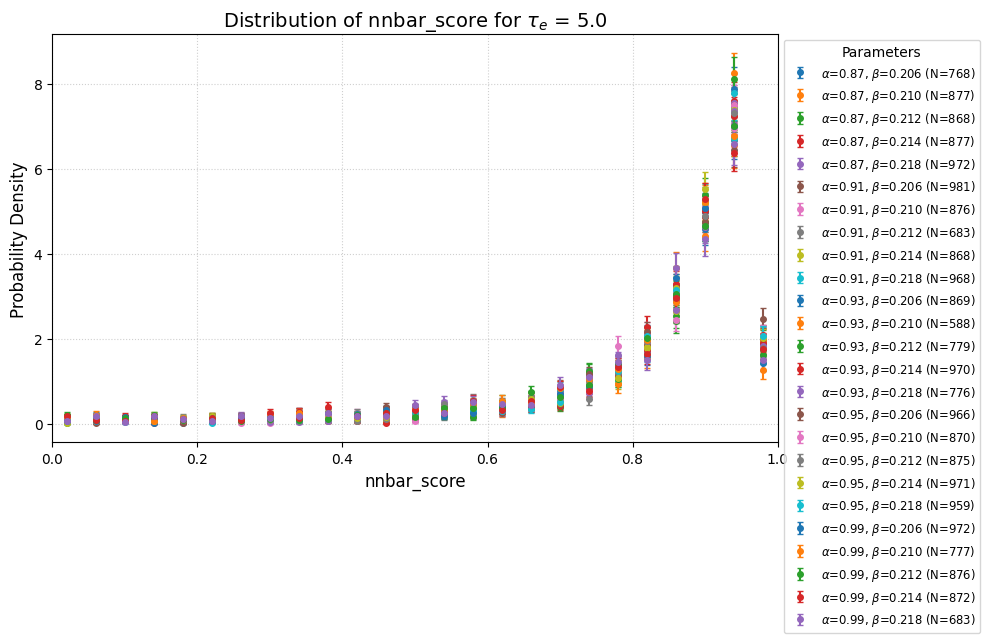

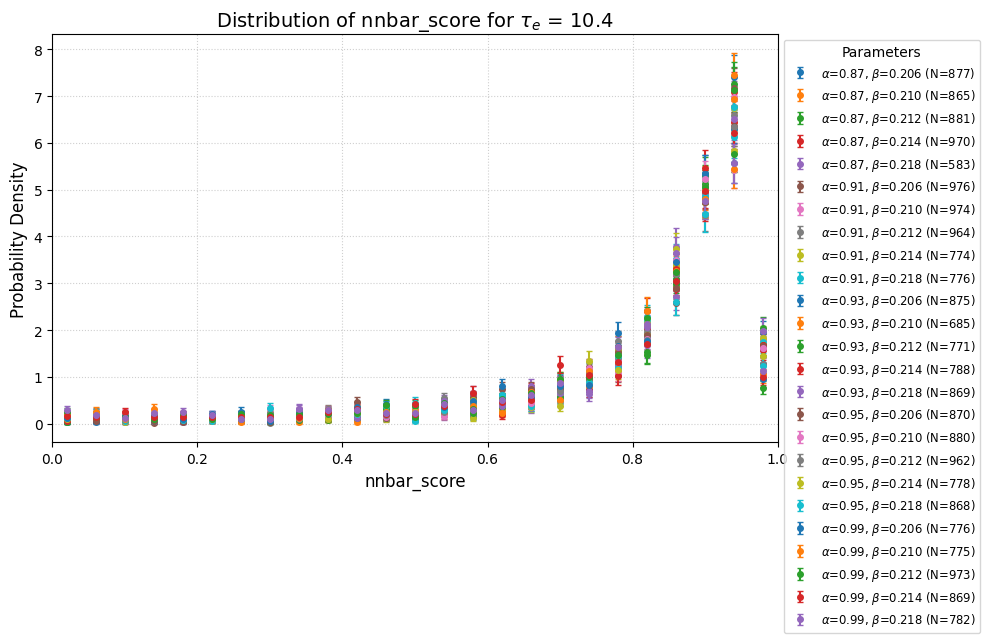

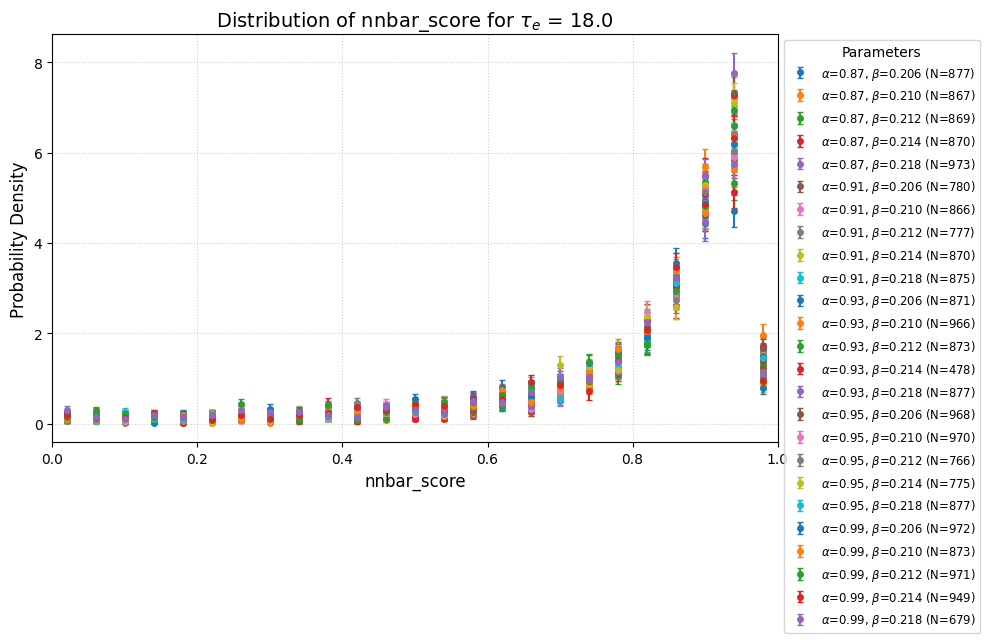

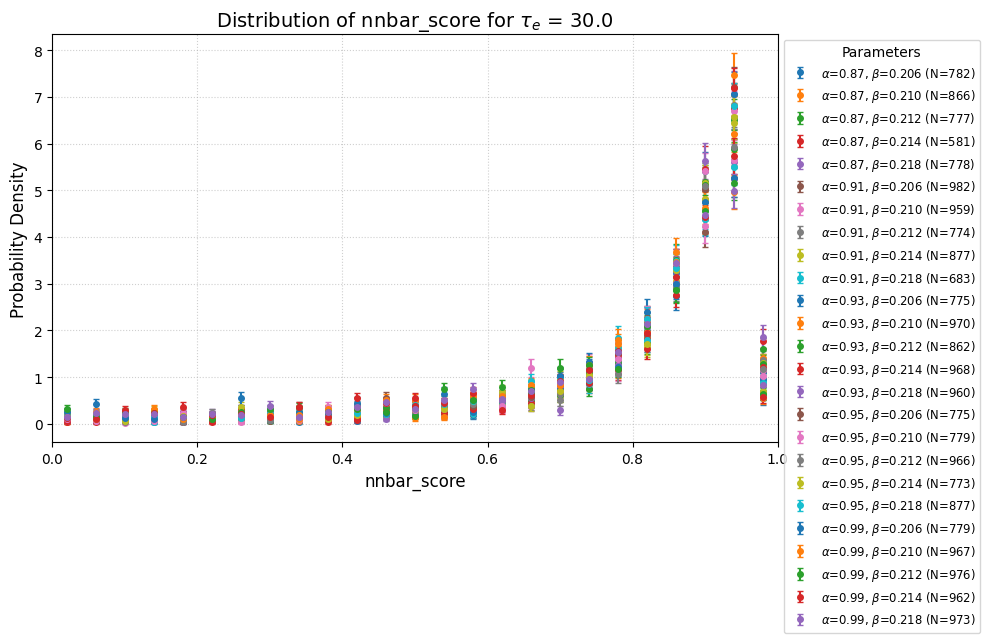

/var/folders/tj/3kjxrxwx2c37zmf4n9j5yh900000gq/T/ipykernel_92297/4266735449.py:21: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  counts, bin_edges = np.histogram(scores, bins=bins, range=plot_range)


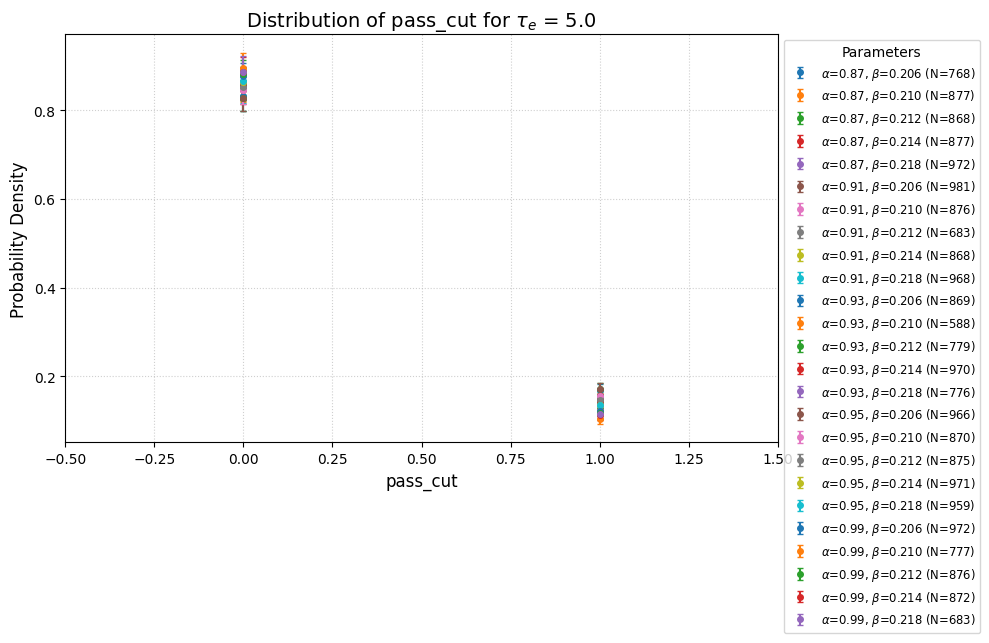

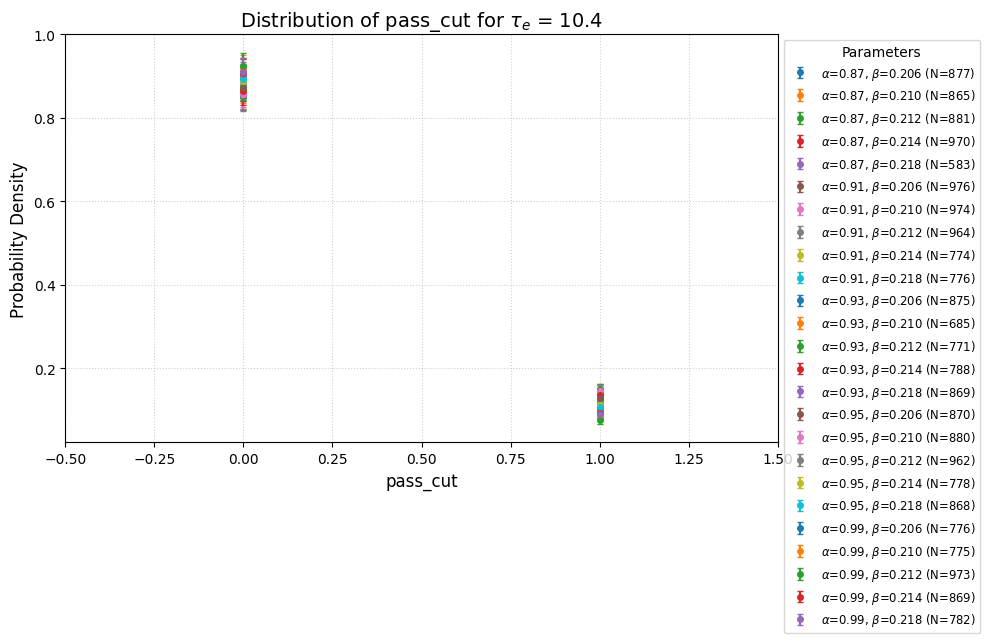

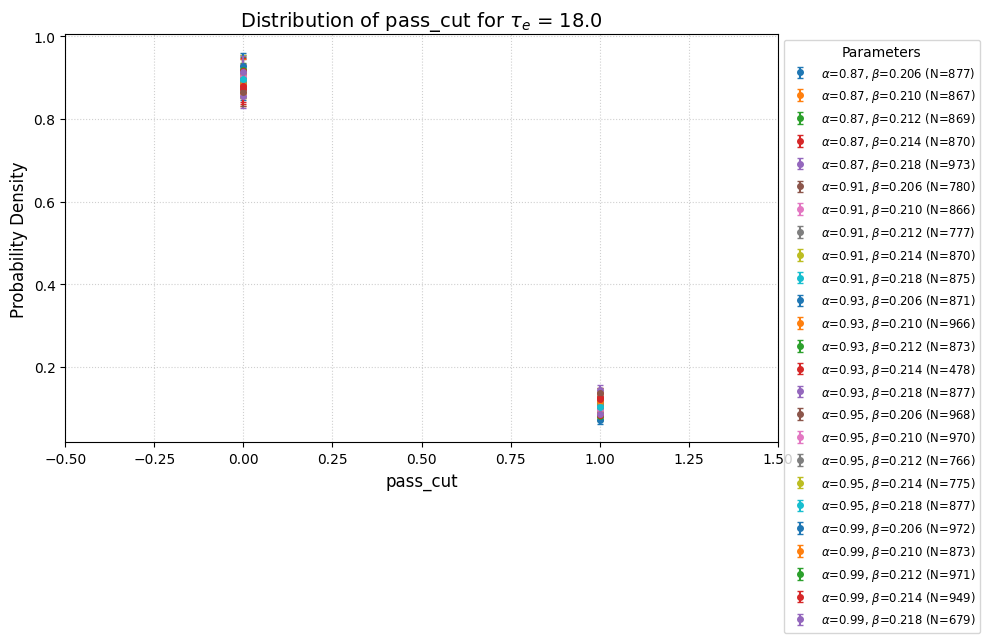

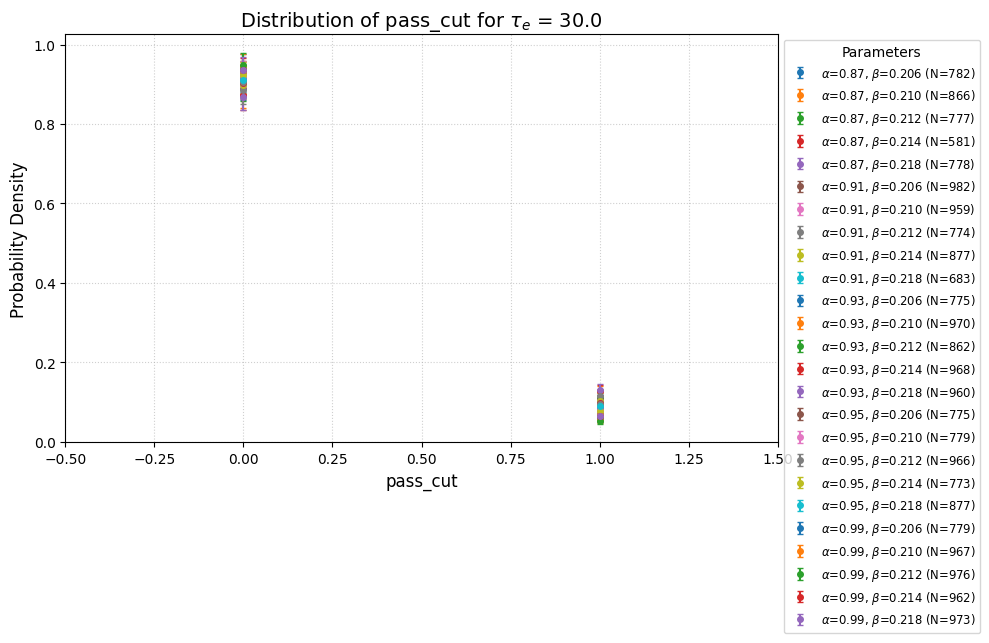

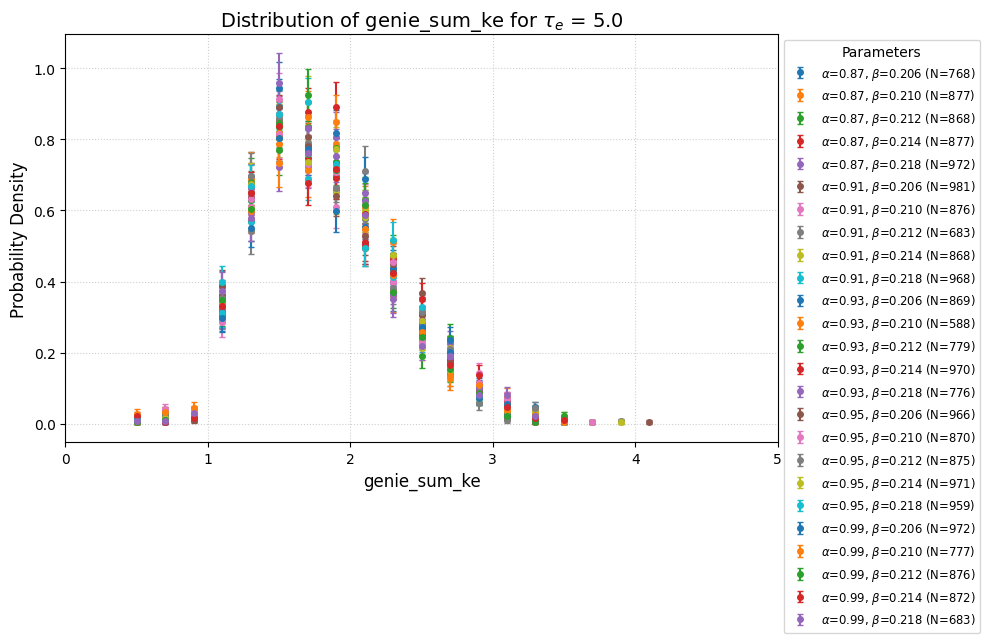

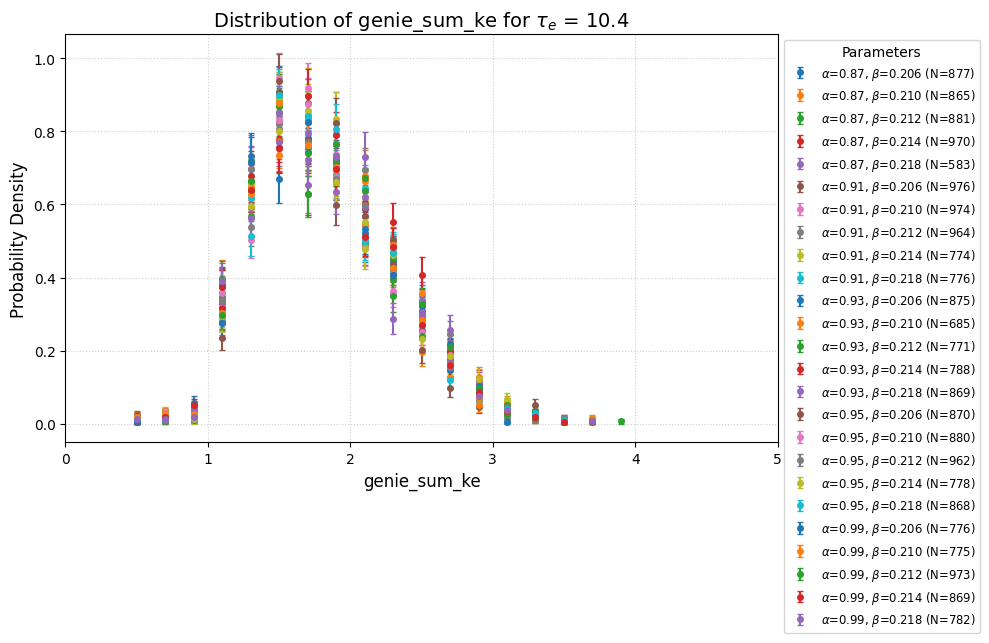

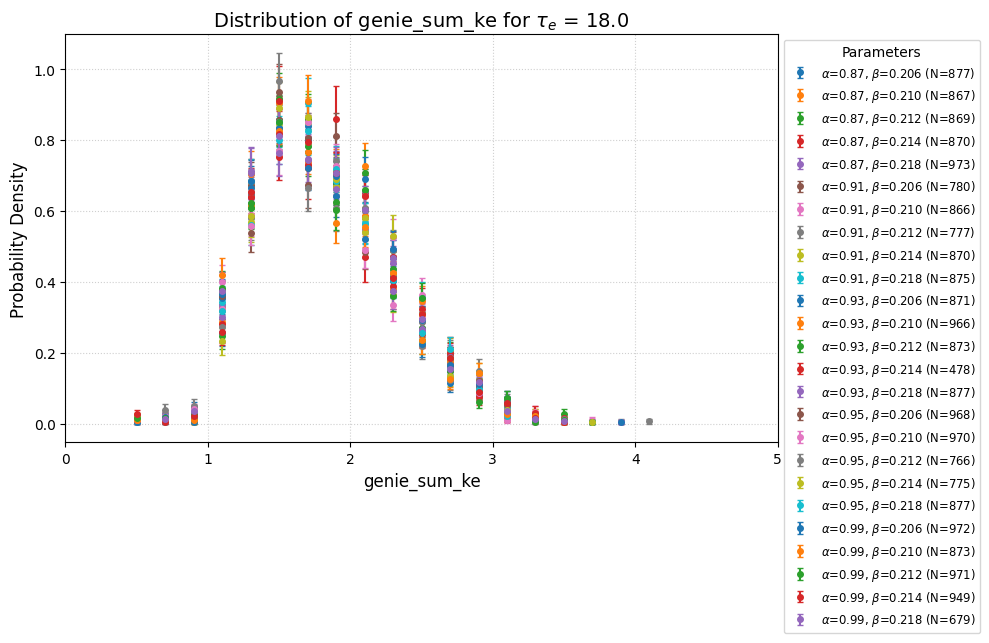

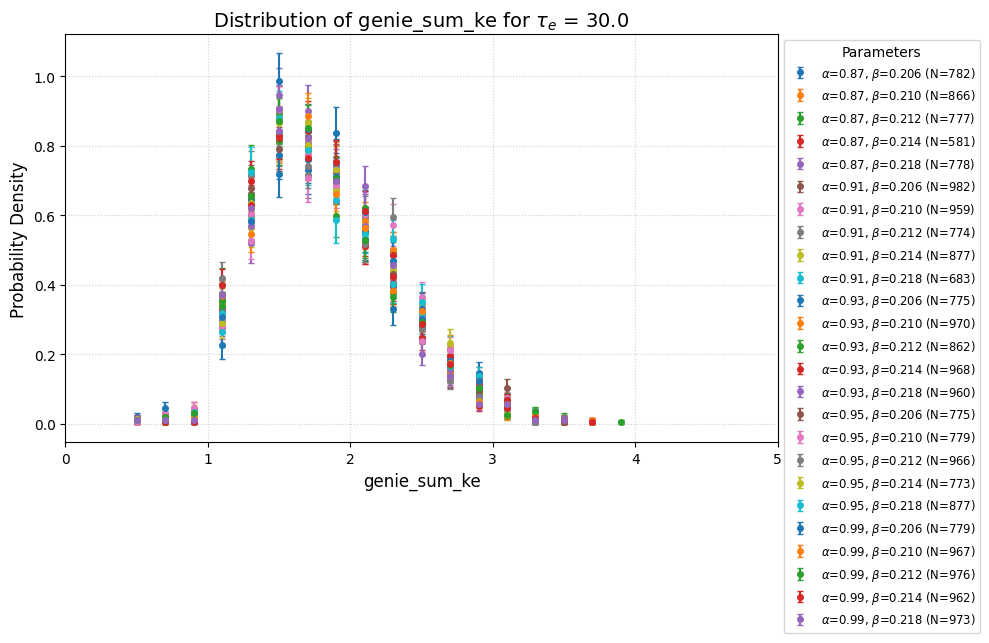

In [13]:
plot_nnbar_points_with_errors_each_etau(lf_df, 'nnbar_score', bins=25, plot_range=(0, 1))
plot_nnbar_points_with_errors_each_etau(lf_df, 'pass_cut', bins=2, plot_range=(-0.5, 1.5))
plot_nnbar_points_with_errors_each_etau(lf_df, 'genie_sum_ke', bins=25, plot_range=(0., 5.))